# EE 413 Project: STFT-Based Spoken Digit Classification

This notebook focuses on the STFT-based analysis part of the Free Spoken Digit Dataset.

The goal is to:
1. Load spoken digit audio files.
2. Apply basic preprocessing.
3. Implement a custom STFT.
4. Study the effect of window length, window type, and overlap.
5. Extract short-time spectral features.
6. Train an SVM classifier and evaluate the result.

I use standard STFT windows only: Hamming, Hann, and Rectangular.

Note: Plotting code was created with help from ChatGPT and checked by me.

## 1. Imports


In [10]:
# File handling and numerical processing
import os
import numpy as np

# Read WAV audio files
from scipy.io import wavfile

# Plotting
import matplotlib.pyplot as plt

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load and normalize dataset

In [11]:
# Download dataset only if it is missing
dataset_root = "/content/free-spoken-digit-dataset"

if not os.path.isdir(dataset_root):
    os.system("git clone -q https://github.com/Jakobovski/free-spoken-digit-dataset.git")

# Folder containing WAV files
data_path = "/content/free-spoken-digit-dataset/recordings"

# Read all WAV filenames
files = sorted([f for f in os.listdir(data_path) if f.endswith(".wav")])

X = []             # audio signals
y = []             # digit labels
file_indices = []  # recording index from filename

for f in files:
    # Example filename: 7_jackson_32.wav
    parts = f.replace(".wav", "").split("_")

    label = int(parts[0])
    file_index = int(parts[2])

    # Read audio file
    fs, data = wavfile.read(os.path.join(data_path, f))

    # Convert to float for DSP calculations
    data = data.astype(np.float32)

    # Normalize signal to range close to [-1, 1]
    max_val = np.max(np.abs(data))
    if max_val > 0:
        data = data / max_val

    X.append(data)
    y.append(label)
    file_indices.append(file_index)

# Convert lists to NumPy arrays
y = np.array(y)
file_indices = np.array(file_indices)

print("Loaded files:", len(X))
print("Sampling rate:", fs, "Hz")
print("Digits:", [int(v) for v in sorted(set(y))])

Loaded files: 3000
Sampling rate: 8000 Hz
Digits: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### 3. Pre-emphasis, windows, and custom STFT

In [12]:
def pre_emphasis(x, alpha=0.97):
    """
    Apply pre-emphasis:
    y[n] = x[n] - alpha*x[n-1]
    """
    return np.append(x[0], x[1:] - alpha * x[:-1])


def make_window(N, window_type="hamming"):
    """
    Create a standard STFT window.
    """
    window_type = window_type.lower()

    if window_type == "hamming":
        return np.hamming(N)

    if window_type == "hann":
        return np.hanning(N)

    if window_type == "rectangular":
        return np.ones(N)

    raise ValueError("Use: hamming, hann, or rectangular")


def custom_stft(x, fs, win_ms=30, overlap=0.5, window_type="hamming"):
    """
    Custom STFT:
    split signal into frames, apply window, then apply rFFT.
    """

    # Convert window length from milliseconds to samples
    N = int(win_ms * fs / 1000)

    # Hop size controls overlap between frames
    hop = int(N * (1 - overlap))

    if N <= 0:
        raise ValueError("Window length must be positive.")

    if hop <= 0:
        raise ValueError("Overlap is too large.")

    # Create selected window
    window = make_window(N, window_type)

    # Pad short signal if needed
    if len(x) < N:
        x = np.pad(x, (0, N - len(x)))

    # Number of STFT frames
    num_frames = 1 + int(np.ceil((len(x) - N) / hop))

    # Pad signal so last frame is complete
    total_len = (num_frames - 1) * hop + N
    x = np.pad(x, (0, total_len - len(x)))

    # STFT matrix: rows are frequency bins, columns are time frames
    S = np.zeros((N // 2 + 1, num_frames), dtype=complex)

    # Frame-by-frame FFT
    for i in range(num_frames):
        start = i * hop
        frame = x[start:start + N]
        S[:, i] = np.fft.rfft(frame * window)

    # Axes for plotting
    freq_axis = np.fft.rfftfreq(N, d=1 / fs)
    time_axis = np.arange(num_frames) * hop / fs

    return S, freq_axis, time_axis

## 4. Plot one example STFT spectrogram

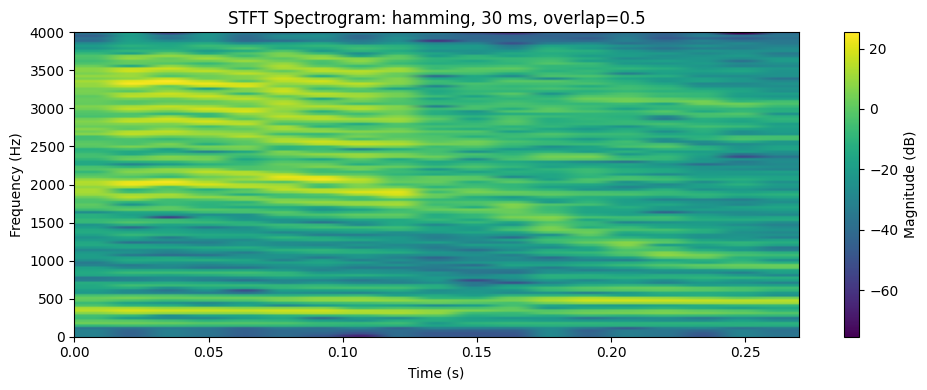

In [13]:
# Choose one example signal
sample = pre_emphasis(X[0])

# Main STFT setting
win_ms = 30
overlap = 0.5
window_type = "hamming"

# Apply STFT
S, f_axis, t_axis = custom_stft(sample, fs, win_ms, overlap, window_type)

# Convert magnitude to dB
S_db = 20 * np.log10(np.abs(S) + 1e-10)

# Plot created with help from ChatGPT and checked by me
plt.figure(figsize=(10, 4))
plt.imshow(
    S_db,
    aspect="auto",
    origin="lower",
    extent=[t_axis[0], t_axis[-1], f_axis[0], f_axis[-1]]
)

plt.title(f"STFT Spectrogram: {window_type}, {win_ms} ms, overlap={overlap}")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Magnitude (dB)")
plt.tight_layout()
plt.show()

## 5. Study window length, window type, and overlap

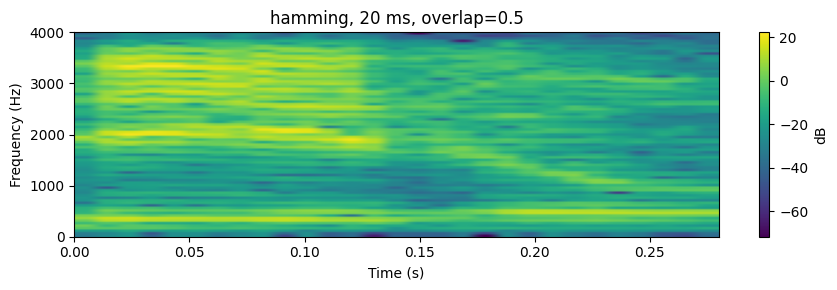

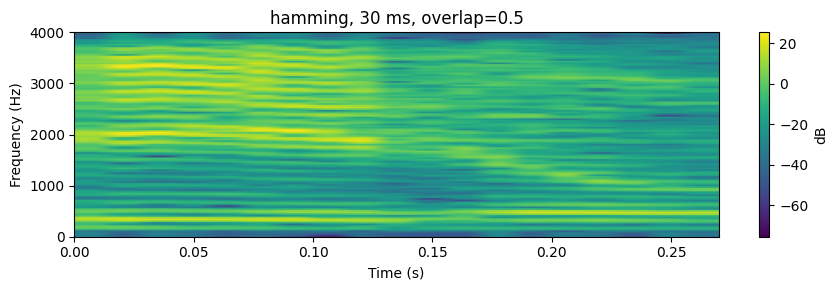

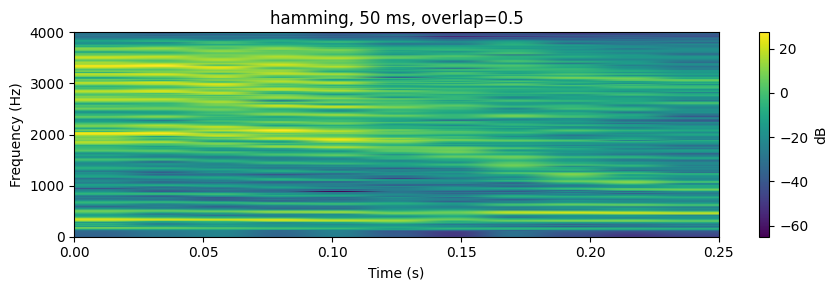

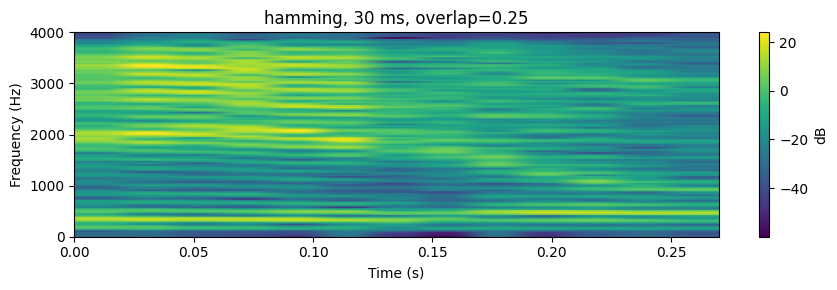

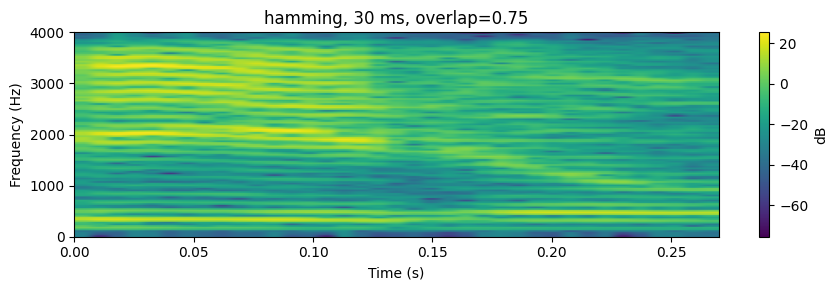

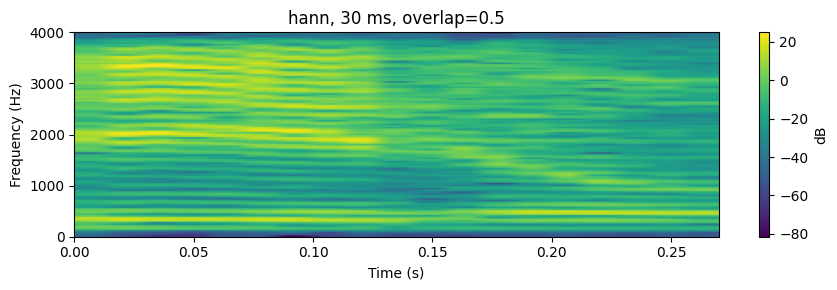

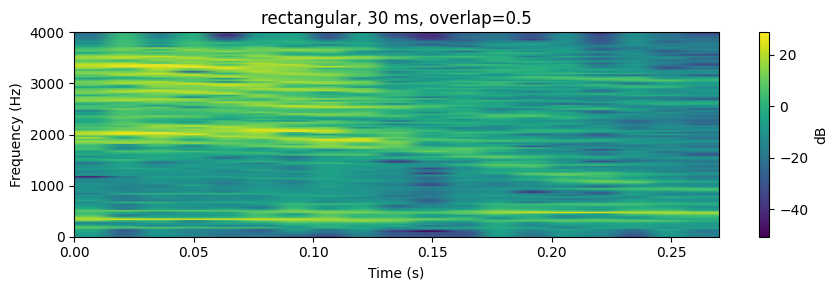

In [14]:
# Settings for STFT comparison
settings = [
    (20, 0.5, "hamming"),       # short window
    (30, 0.5, "hamming"),       # default window
    (50, 0.5, "hamming"),       # long window
    (30, 0.25, "hamming"),      # lower overlap
    (30, 0.75, "hamming"),      # higher overlap
    (30, 0.5, "hann"),          # Hann window
    (30, 0.5, "rectangular")    # Rectangular window
]

for win_ms, overlap, window_type in settings:
    # Apply STFT with current setting
    S, f_axis, t_axis = custom_stft(sample, fs, win_ms, overlap, window_type)

    # Convert to dB
    S_db = 20 * np.log10(np.abs(S) + 1e-10)

    # Plot created with help from ChatGPT and checked by me
    plt.figure(figsize=(9, 3))
    plt.imshow(
        S_db,
        aspect="auto",
        origin="lower",
        extent=[t_axis[0], t_axis[-1], f_axis[0], f_axis[-1]]
    )

    plt.title(f"{window_type}, {win_ms} ms, overlap={overlap}")
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.colorbar(label="dB")
    plt.tight_layout()
    plt.show()

## 6. Extract short-time spectral features

In [15]:
def stft_features(x, fs, win_ms=30, overlap=0.5, window_type="hamming"):
    """
    Extract short-time spectral features from STFT.
    """

    # Preprocess signal
    x = pre_emphasis(x)

    # Compute STFT
    S, f_axis, t_axis = custom_stft(x, fs, win_ms, overlap, window_type)

    # Magnitude spectrogram
    mag = np.abs(S)

    # Log spectrum statistics for each frequency bin
    log_mag = np.log1p(mag)
    log_mean = np.mean(log_mag, axis=1)
    log_std = np.std(log_mag, axis=1)

    # Spectral centroid for each frame
    denom = np.sum(mag, axis=0) + 1e-10
    centroid = np.sum(f_axis[:, None] * mag, axis=0) / denom

    # Spectral bandwidth for each frame
    bandwidth = np.sqrt(
        np.sum(((f_axis[:, None] - centroid[None, :]) ** 2) * mag, axis=0) / denom
    )

    # Combine all features into one vector
    feature_vector = np.concatenate([
        log_mean,
        log_std,
        [np.mean(centroid), np.std(centroid)],
        [np.mean(bandwidth), np.std(bandwidth)]
    ])

    return feature_vector

## 7. Build feature matrix and train SVM


In [16]:
# Chosen STFT setting for classification
best_win_ms = 30
best_overlap = 0.5
best_window = "hamming"

# Extract features for all files
X_feat = []

for signal in X:
    feat = stft_features(signal, fs, best_win_ms, best_overlap, best_window)
    X_feat.append(feat)

X_feat = np.array(X_feat)
X_feat = np.nan_to_num(X_feat)

print("Feature matrix shape:", X_feat.shape)

# 80/20 train/test split
# indices 0 to 9 are test files, others are training files
test_mask = file_indices <= 9
train_mask = ~test_mask

X_train = X_feat[train_mask]
X_test = X_feat[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))

# Scale features before SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train SVM classifier
clf = SVC(kernel="rbf", C=10, gamma="scale")
clf.fit(X_train_scaled, y_train)

# Predict test labels
y_pred = clf.predict(X_test_scaled)

# Evaluate
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred))

Feature matrix shape: (3000, 246)
Training samples: 2400
Testing samples: 600
Accuracy: 98.33%
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        60
           1       1.00      0.97      0.98        60
           2       0.98      0.98      0.98        60
           3       0.97      0.95      0.96        60
           4       0.98      1.00      0.99        60
           5       0.98      1.00      0.99        60
           6       0.94      0.98      0.96        60
           7       1.00      1.00      1.00        60
           8       1.00      0.97      0.98        60
           9       1.00      1.00      1.00        60

    accuracy                           0.98       600
   macro avg       0.98      0.98      0.98       600
weighted avg       0.98      0.98      0.98       600



## 8. Confusion matrix

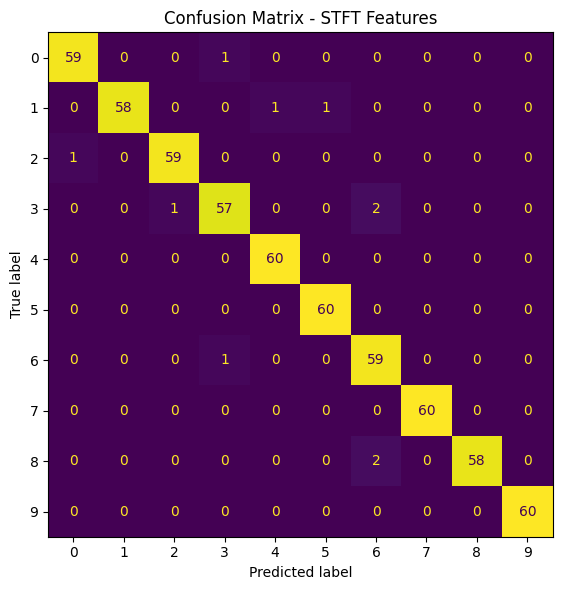

In [17]:
cm = confusion_matrix(y_test, y_pred)

# Plot created with help from ChatGPT and checked by me
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(set(y))
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False)

plt.title("Confusion Matrix - STFT Features")
plt.tight_layout()
plt.show()

## Summary

I implemented STFT-based analysis for spoken digit classification.

First, I loaded and normalized the audio signals. Then I applied pre-emphasis.

For STFT, I divided each signal into overlapping frames, applied a selected window, and computed `np.fft.rfft()` for each frame.

I studied the effect of window length, overlap, and window type using spectrogram plots.

From the STFT, I extracted short-time spectral features: log-spectrum statistics, spectral centroid, and spectral bandwidth.

Finally, I trained an SVM classifier and evaluated the result using accuracy, classification report, and confusion matrix.

Plotting code was created with help from ChatGPT and checked by me.